In [ ]:
!pip install --upgrade biopython wordcloud transformers tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 26.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.19.0
    Uninstalling tf_keras-2.19.0:
      Successfully uninstalled tf_keras-2.19.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstal

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.41.2 tf-keras

Found existing installation: transformers 5.2.0
Uninstalling transformers-5.2.0:
  Successfully uninstalled transformers-5.2.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 28.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from Bio import Entrez
from transformers import AutoTokenizer, TFAutoModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/NLP_Project_Final'
CSV_PATH = os.path.join(SAVE_DIR, 'pubmed_dataset_final.csv')

df = pd.read_csv(CSV_PATH)

Mounted at /content/drive


In [ ]:
display(df.head(10))

,text,methodology
0,Clinical evidence of traditional Chinese medic...,Randomized Controlled Trial
1,Vaccine co-administration is common in childho...,Randomized Controlled Trial
2,Intravenous (IV) acetaminophen is widely used ...,Randomized Controlled Trial
3,This study evaluates the feasibility of photon...,Randomized Controlled Trial
4,Beetroot juice (BRJ) supplementation has the p...,Randomized Controlled Trial
5,To investigate the synergistic effect of three...,Randomized Controlled Trial
6,Chronic Obstructive Pulmonary Disease (COPD) i...,Randomized Controlled Trial
7,This study aimed to evaluate the effects of gr...,Randomized Controlled Trial
8,Platelet-rich plasma (PRP) has been widely app...,Randomized Controlled Trial
9,This study aimed to determine the preferable c...,Randomized Controlled Trial


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39996 entries, 0 to 39995
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         39996 non-null  object
 1   methodology  39996 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


None

In [ ]:
display(df.describe())

,text,methodology
count,39996,39996
unique,39929,4
top,﻿Abstract.,Randomized Controlled Trial
freq,5,9999


In [ ]:
display(df.isnull().sum())

,0
text,0
methodology,0


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
len_before = len(df)

df['clean_text'] = df['text'].apply(clean_text)
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f"Deleted {len_before - len(df)} duplicate articles. Total remaining: {len(df)}")

Deleted 70 duplicate articles. Total remaining: 39926


In [ ]:
cleaned_csv = os.path.join(SAVE_DIR, 'pubmed_cleaned_data.csv')
df.to_csv(cleaned_csv, index=False, encoding='utf-8-sig')

print(f"\n[SUCCESS] Cleaned data saved to: {cleaned_csv}")
display(df[['methodology', 'clean_text']].head())


[SUCCESS] Cleaned data saved to: /content/drive/MyDrive/NLP_Project_Final/pubmed_cleaned_data.csv


,methodology,clean_text
0,Randomized Controlled Trial,clinical evidence of traditional chinese medic...
1,Randomized Controlled Trial,vaccine co administration is common in childho...
2,Randomized Controlled Trial,intravenous iv acetaminophen is widely used in...
3,Randomized Controlled Trial,this study evaluates the feasibility of photon...
4,Randomized Controlled Trial,beetroot juice brj supplementation has the pot...


In [ ]:
SAVE_RS = '/content/drive/MyDrive/NLP_Project_Final/Results'
if not os.path.exists(SAVE_RS):
    os.makedirs(SAVE_RS)

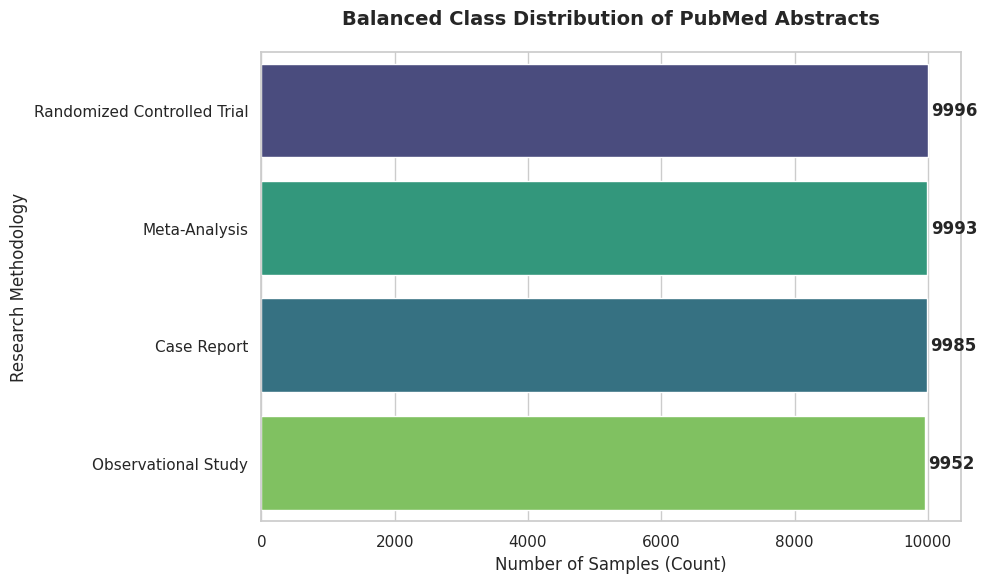

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    y='methodology',
    palette='viridis',
    hue='methodology',
    legend=False,
    order = df['methodology'].value_counts().index
)

plt.title("Balanced Class Distribution of PubMed Abstracts", fontweight='bold', fontsize=14, pad=20)
plt.xlabel("Number of Samples (Count)", fontsize=12)
plt.ylabel("Research Methodology", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 50, p.get_y() + p.get_height()/2,
            f'{int(width)}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_RS, 'class_distribution.png'), dpi=300)
plt.show()

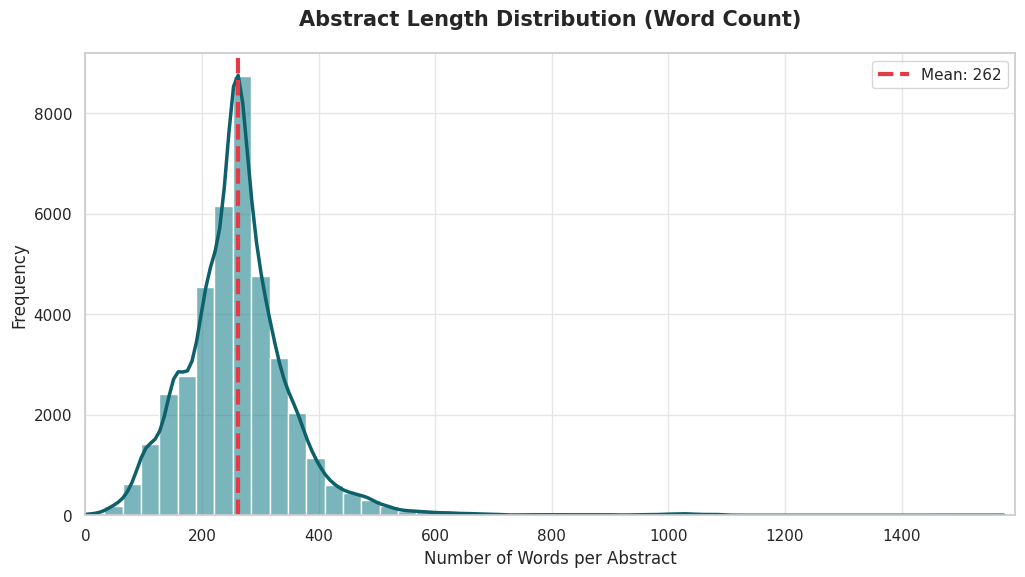

In [ ]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
mean_len = df['word_count'].mean()
median_len = df['word_count'].median()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.color': '.9'})

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True,
    color='#20858d',
    edgecolor='white',
    linewidth=1,
    alpha=0.6
)

line = plt.gca().lines[0]
line.set_color('#0e606b')
line.set_linewidth(2.5)

plt.axvline(mean_len, color='#e63946', linestyle='--', linewidth=3, label=f'Mean: {mean_len:.0f}')

plt.title("Abstract Length Distribution (Word Count)", fontweight='bold', fontsize=15, pad=20)
plt.xlabel("Number of Words per Abstract", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.legend(fontsize=11, frameon=True)
plt.xlim(0, df['word_count'].max() + 20)

plt.savefig(os.path.join(SAVE_RS, 'length_distribution_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
suggested_max = int(mean_len + 50)
print(f">>> [DECISION] MAX_SEQUENCE_LENGTH = {suggested_max}")

>>> [DECISION] MAX_SEQUENCE_LENGTH = 311


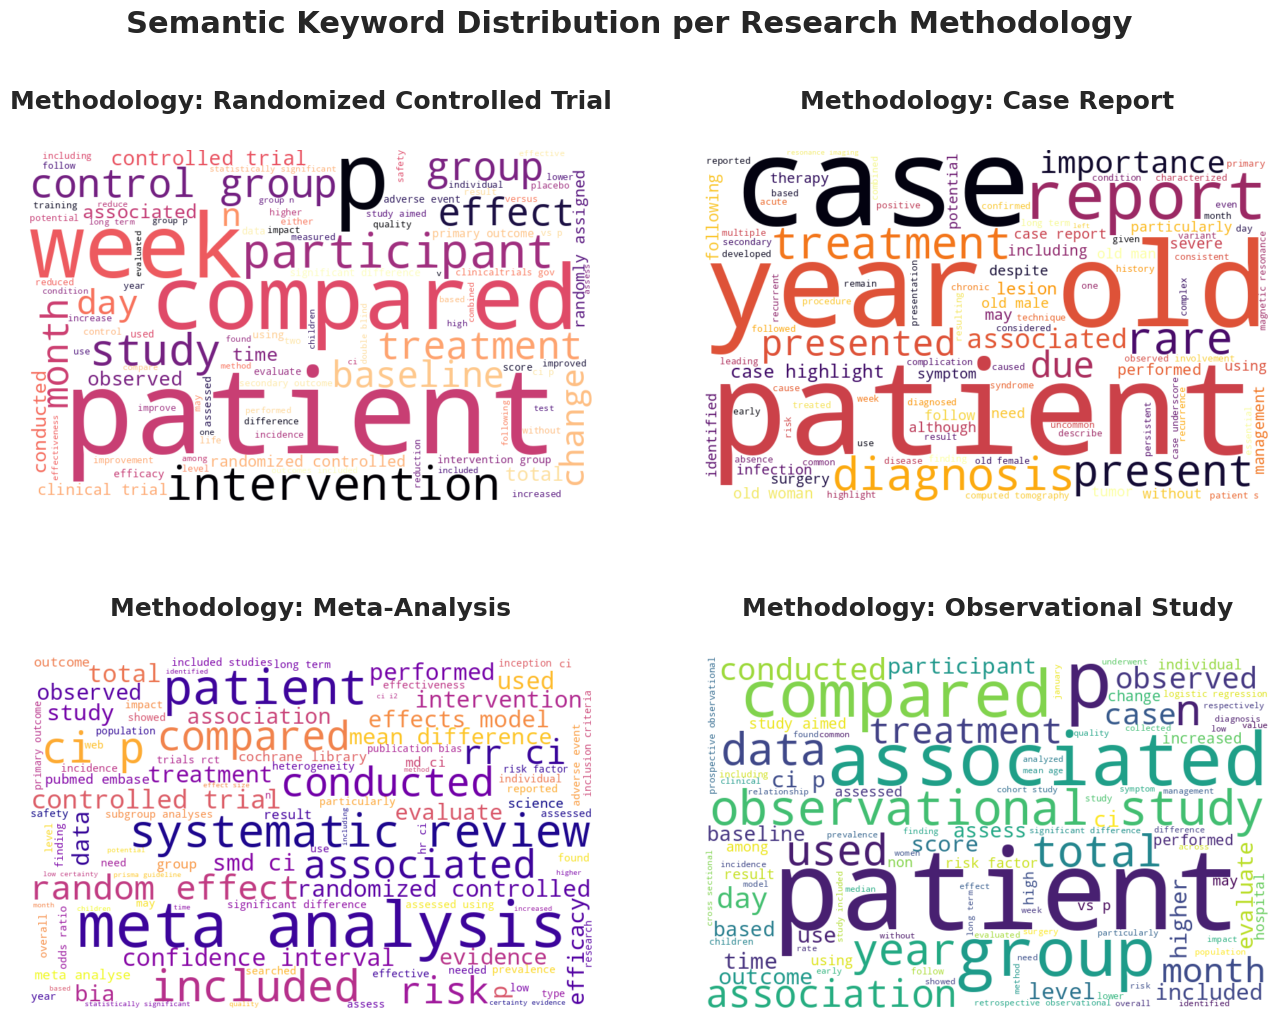

In [ ]:
fig = plt.figure(figsize=(16, 12))
plt.clf()

axes = fig.subplots(2, 2, gridspec_kw={'top': 0.9, 'hspace': 0.15})
axes = axes.flatten()

colormaps = ['magma', 'inferno', 'plasma', 'viridis']
unique_labels = df['methodology'].unique()

for i, label in enumerate(unique_labels):
    text_corpus = " ".join(df[df['methodology'] == label]['clean_text'])

    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        max_words=100,
        colormap=colormaps[i],
        random_state=42
    ).generate(text_corpus)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Methodology: {label}', fontsize=18, fontweight='bold', pad=30)
    axes[i].axis('off')

plt.suptitle("Semantic Keyword Distribution per Research Methodology",
             fontsize=22, fontweight='bold', y=0.98)

wordcloud_path = os.path.join(SAVE_RS, 'wordcloud.png')
plt.savefig(wordcloud_path, dpi=300, bbox_inches='tight')

plt.show()